## Declare required dependencies

In [ ]:
import pandas as pd
import numpy as np
import pickle

from torch.autograd import Variable
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


import torch.utils.data as data_utils
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc,
                             roc_curve, recall_score, classification_report, f1_score,
                             precision_recall_fscore_support)

sns.set(style='whitegrid', palette='muted', font_scale=1.5)

rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42
LABELS = ["Normal", "Fraud"]

## Data ingestion

In [ ]:
# Загрузка данных из Excel файла
df = pd.read_excel('Real estate valuation data set.xlsx')


## Data exploration

In [ ]:
df.head(5)

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,Возраст дома,Кол-во магазинов,Расстояние до ближайшей станции метро
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9,старый,много,далеко
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2,старый,много,далеко
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3,старый,среднее,далеко
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8,старый,среднее,далеко
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1,новостройка,среднее,далеко


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
df[['Возраст дома', 'Кол-во магазинов', 'Расстояние до ближайшей станции метро']] = enc.fit_transform(df[['Возраст дома', 'Кол-во магазинов', 'Расстояние до ближайшей станции метро']])
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,Возраст дома,Кол-во магазинов,Расстояние до ближайшей станции метро
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9,1.0,1.0,1.0
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2,1.0,1.0,1.0
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3,1.0,2.0,1.0
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8,1.0,2.0,1.0
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1,0.0,2.0,1.0


In [ ]:
print(df.shape)
print(df.describe())

(414, 11)
               No  X1 transaction date  X2 house age  \
count  414.000000           414.000000    414.000000   
mean   207.500000          2013.148953     17.712560   
std    119.655756             0.281995     11.392485   
min      1.000000          2012.666667      0.000000   
25%    104.250000          2012.916667      9.025000   
50%    207.500000          2013.166667     16.100000   
75%    310.750000          2013.416667     28.150000   
max    414.000000          2013.583333     43.800000   

       X3 distance to the nearest MRT station  \
count                              414.000000   
mean                              1083.885689   
std                               1262.109595   
min                                 23.382840   
25%                                289.324800   
50%                                492.231300   
75%                               1454.279000   
max                               6488.021000   

       X4 number of convenience stores  X5 

In [ ]:
df.isnull().values.any()

np.False_

In [ ]:
df['Возраст дома'].value_counts()

,count
Возраст дома,
1.0,305
0.0,109


/tmp/ipykernel_3187/3197995787.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['Возраст дома'], sort = True)


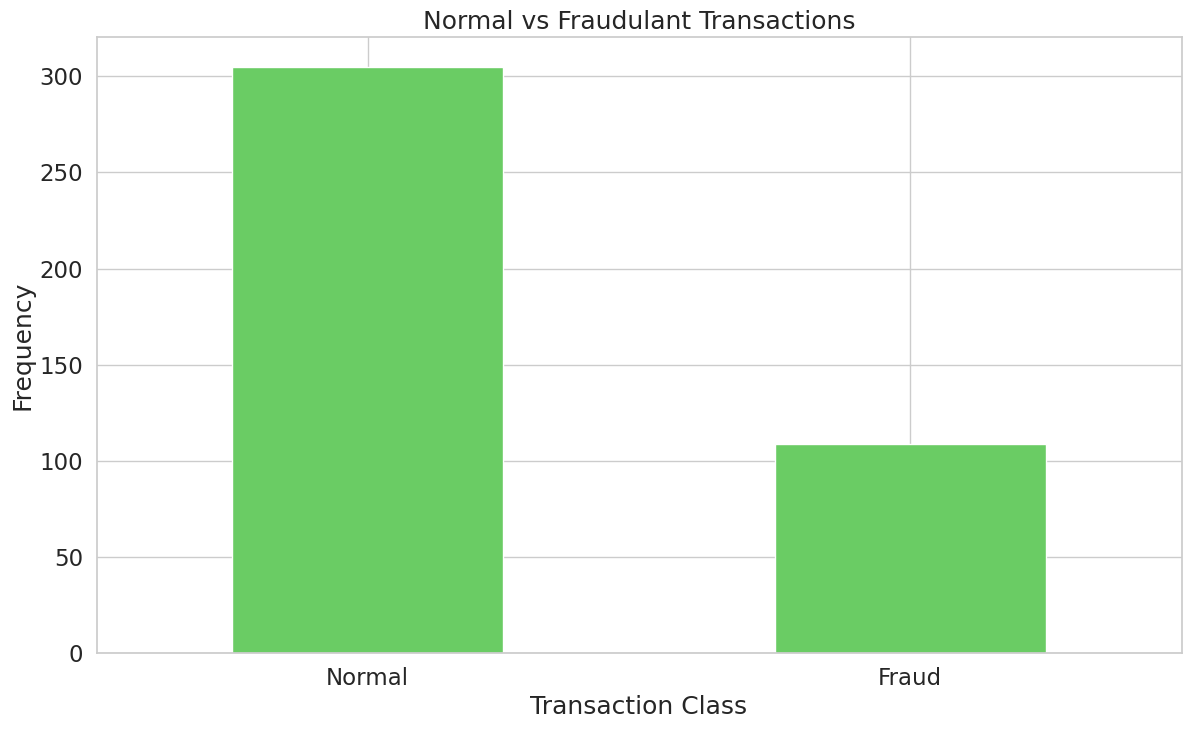

In [ ]:
count_classes = pd.value_counts(df['Возраст дома'], sort = True)
count_classes.plot(kind = 'bar', rot=0, color="g")
plt.title("Normal vs Fraudulant Transactions")
plt.xticks(range(2), LABELS)
plt.xlabel("Transaction Class")
plt.ylabel("Frequency");

In [ ]:
df = df.rename(columns={'Возраст дома': 'Возраст_дома','Кол-во магазинов':'Кол-во_магазинов', 'Расстояние до ближайшей станции метро': 'Расстояние_до_ближайшей_станции_метро'})

In [ ]:
fraudsDF = df[df.Возраст_дома == 1]
normalDF = df[df.Возраст_дома == 0]

In [ ]:
fraudsDF.shape

(305, 11)

In [ ]:
normalDF.shape

(109, 11)

In [ ]:
fraudsDF.Возраст_дома.describe()

,Возраст_дома
count,305.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [ ]:
normalDF.Возраст_дома.describe()

,Возраст_дома
count,109.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [ ]:
df.head(5)

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,Возраст_дома,Кол-во_магазинов,Расстояние_до_ближайшей_станции_метро
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9,1.0,1.0,1.0
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2,1.0,1.0,1.0
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3,1.0,2.0,1.0
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8,1.0,2.0,1.0
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1,0.0,2.0,1.0


### Разделите набор данных на наборы обучающих и тестовых данных.

In [ ]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=RANDOM_SEED)
X_train = X_train[X_train.Возраст_дома == 0]
X_train = X_train.drop(['Возраст_дома'], axis=1)
#print(type(X_train))
y_test = X_test['Возраст_дома']
X_test = X_test.drop(['Возраст_дома'], axis=1)

X_train = X_train.values
#print(type(X_train))
X_test = X_test.values
y_test = y_test.values
print(y_test.size)


83


In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(10, 14),
            nn.Tanh(),
            nn.Linear(14, 7),
            nn.LeakyReLU(),
            )

        self.decoder = nn.Sequential(
   nn.Linear(7, 7),
   nn.Tanh(),
   nn.Linear(7, 10)  # ✅ Без активации — линейный выход для реконструкции
   )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
model = Autoencoder().double()

In [ ]:
num_epochs = 100   # сколько эпох будем обучать. Результаты обучения на одной эпохе используются как начальные для следующей.
minibatch_size = 32
learning_rate = 1e-3

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
train_loader = data_utils.DataLoader(X_train_scaled, batch_size=minibatch_size, shuffle=True)

In [ ]:
test_loader = data_utils.DataLoader(X_test_scaled, batch_size=1, shuffle=False)

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
model.parameters(), lr=learning_rate, weight_decay=10e-05)

In [ ]:
history = {}
history['train_loss'] = []
history['test_loss'] = []

In [ ]:
for epoch in range(num_epochs):
    h = np.array([])
    for data in train_loader:
        #print(type(data))
        #data = Variable(data).cpu()
        #print(type(data))
        # ===================forward=====================
        output = model(data)
        loss = criterion(output, data)
        h = np.append(h, loss.item())

        # ===================backward====================
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # ===================log========================
    mean_loss = np.mean(h)
    print('epoch [{}/{}], loss:{:.4f}'
          .format(epoch + 1, num_epochs, mean_loss))
    history['train_loss'].append(mean_loss)


#torch.save(model.state_dict(), './credit_card_model.pth')

epoch [1/100], loss:1.0485
epoch [2/100], loss:1.0259
epoch [3/100], loss:1.0441
epoch [4/100], loss:1.0232
epoch [5/100], loss:1.0224
epoch [6/100], loss:1.0199
epoch [7/100], loss:1.0068
epoch [8/100], loss:0.9934
epoch [9/100], loss:0.9900
epoch [10/100], loss:0.9926
epoch [11/100], loss:0.9794
epoch [12/100], loss:0.9783
epoch [13/100], loss:0.9834
epoch [14/100], loss:0.9626
epoch [15/100], loss:0.9581
epoch [16/100], loss:0.9558
epoch [17/100], loss:0.9486
epoch [18/100], loss:0.9522
epoch [19/100], loss:0.9575
epoch [20/100], loss:0.9391
epoch [21/100], loss:0.9295
epoch [22/100], loss:0.9196
epoch [23/100], loss:0.9125
epoch [24/100], loss:0.9268
epoch [25/100], loss:0.9039
epoch [26/100], loss:0.8979
epoch [27/100], loss:0.9039
epoch [28/100], loss:0.8802
epoch [29/100], loss:0.8792
epoch [30/100], loss:0.8752
epoch [31/100], loss:0.8748
epoch [32/100], loss:0.8585
epoch [33/100], loss:0.8472
epoch [34/100], loss:0.8387
epoch [35/100], loss:0.8359
epoch [36/100], loss:0.8300
e

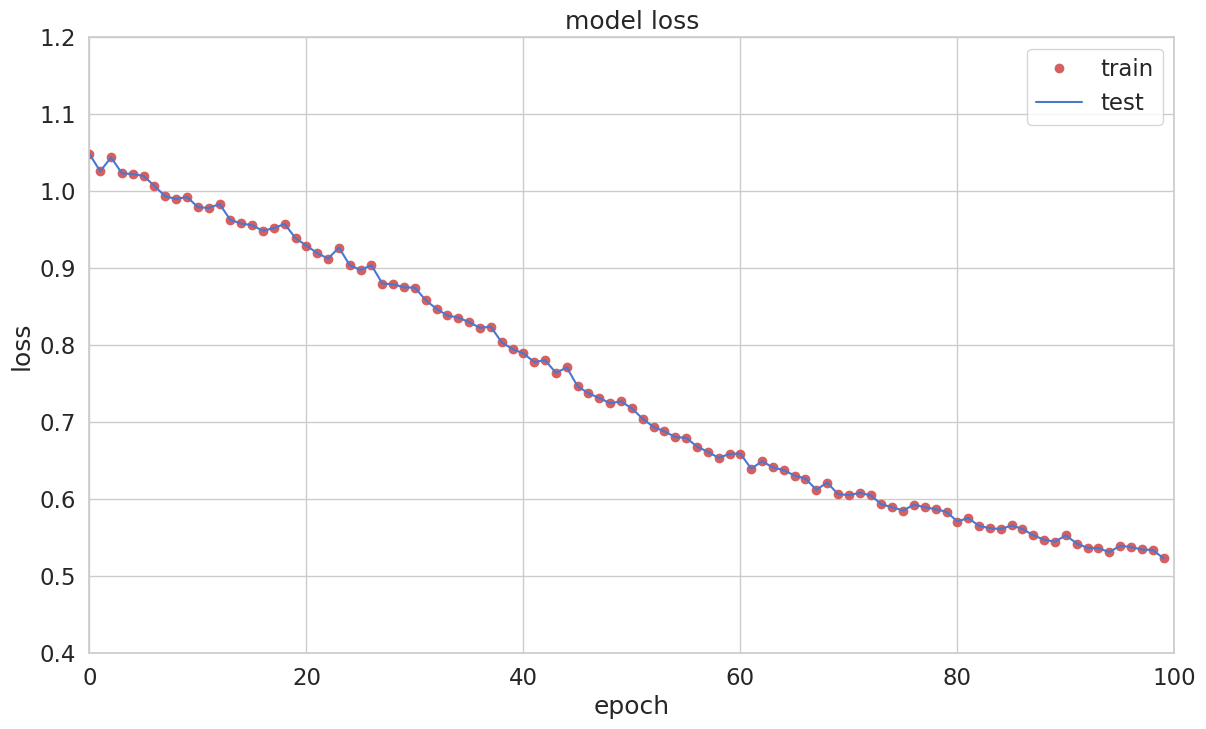

In [ ]:
history['train_loss']
plt.plot(range(num_epochs),history['train_loss'],'ro',linewidth=2.0)
plt.plot(history['train_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.axis([0,100,0.4,1.2])
plt.legend(['train', 'test'], loc='upper right');
plt.show()

In [ ]:
pred_losses = {'pred_loss' : []}
model.eval()
with torch.no_grad():
   # test_loss = 0
    for data in test_loader:
        inputs = data
        # print(inputs)
        outputs = model(inputs)
        loss = criterion(outputs, inputs).data.item()
        #print(loss)
        pred_losses['pred_loss'].append(loss)
        #pred_losses = model([y_test.size, y_test])
reconstructionErrorDF = pd.DataFrame(pred_losses)
reconstructionErrorDF['Возраст_дома'] = y_test

In [ ]:
reconstructionErrorDF.describe()

,pred_loss,Возраст_дома
count,83.000000,83.000000
mean,4.668327,0.795181
std,4.548658,0.406023
min,0.190243,0.000000
25%,1.102230,1.000000
50%,2.649955,1.000000
75%,7.922331,1.000000
max,15.848248,1.000000


In [ ]:
reconstructionErrorDF.describe()

,pred_loss,Возраст_дома
count,83.000000,83.000000
mean,4.668327,0.795181
std,4.548658,0.406023
min,0.190243,0.000000
25%,1.102230,1.000000
50%,2.649955,1.000000
75%,7.922331,1.000000
max,15.848248,1.000000


# Reconstruction Errors without Fraud

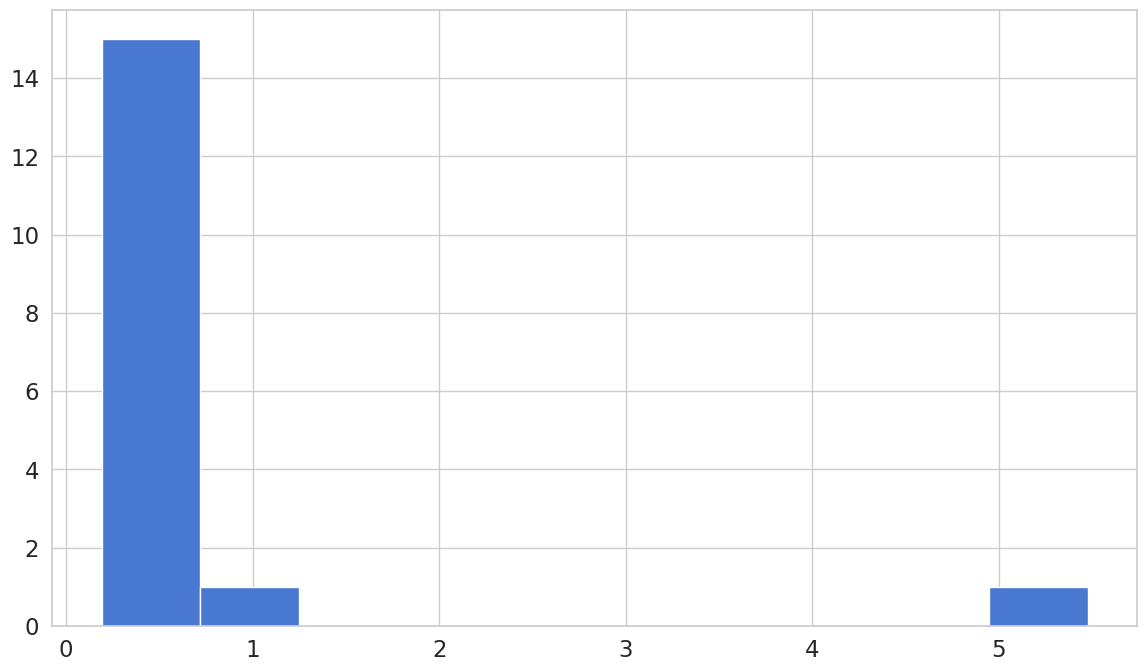

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
normal_error_df = reconstructionErrorDF[(reconstructionErrorDF['Возраст_дома']== 0) & (reconstructionErrorDF['pred_loss'] < 10)]
_ = ax.hist(normal_error_df.pred_loss.values, bins=10)

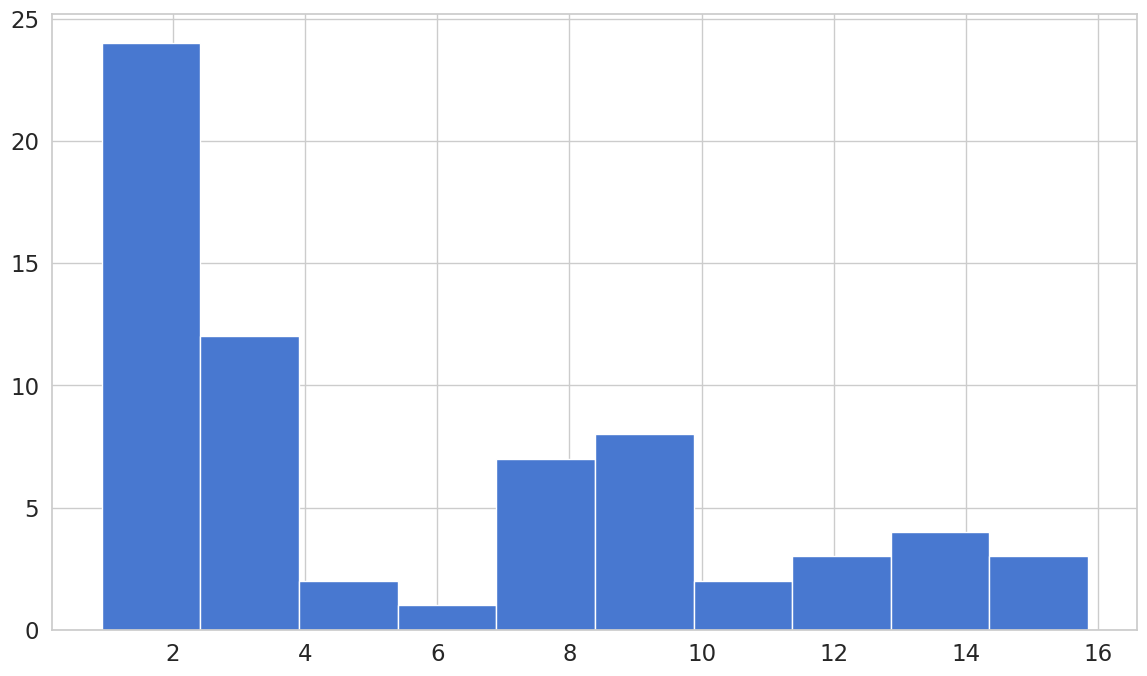

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
fraud_error_df = reconstructionErrorDF[(reconstructionErrorDF['Возраст_дома']== 1) ]
_ = ax.hist(fraud_error_df.pred_loss.values, bins=10)

## ROC Curves

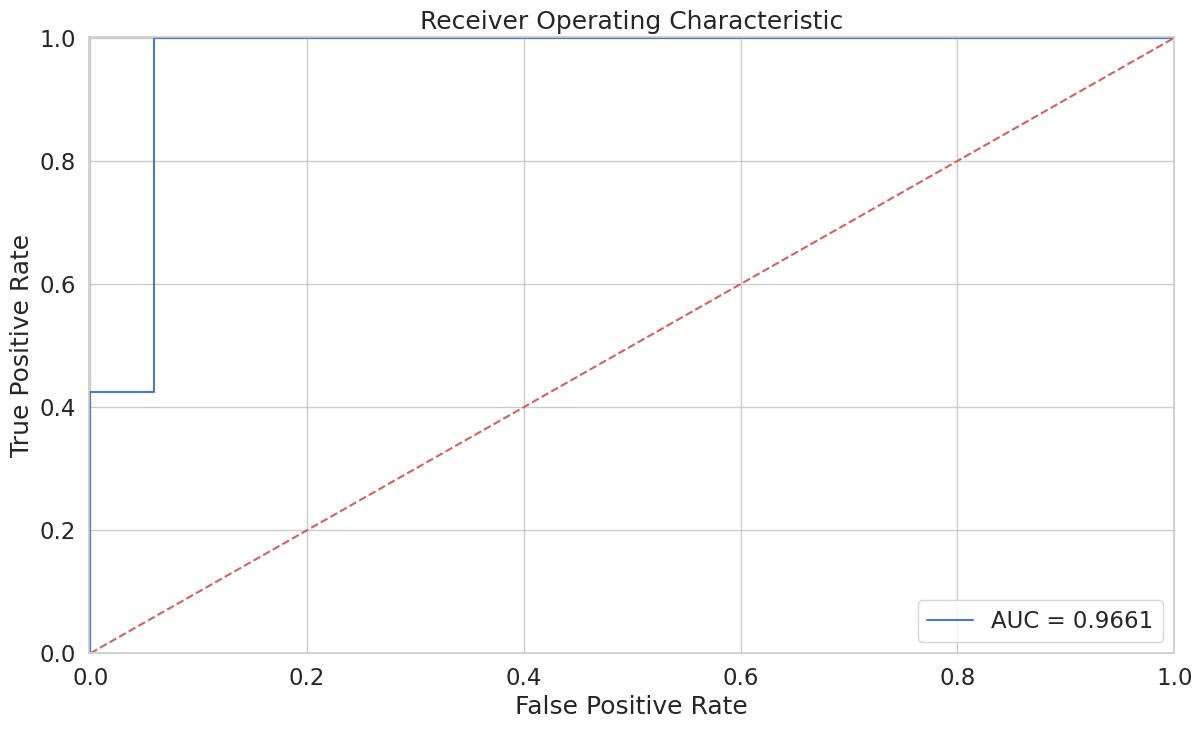

In [ ]:
fpr, tpr, thresholds = roc_curve(reconstructionErrorDF.Возраст_дома, reconstructionErrorDF.pred_loss)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, label='AUC = %0.4f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.001, 1])
plt.ylim([0, 1.001])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show();

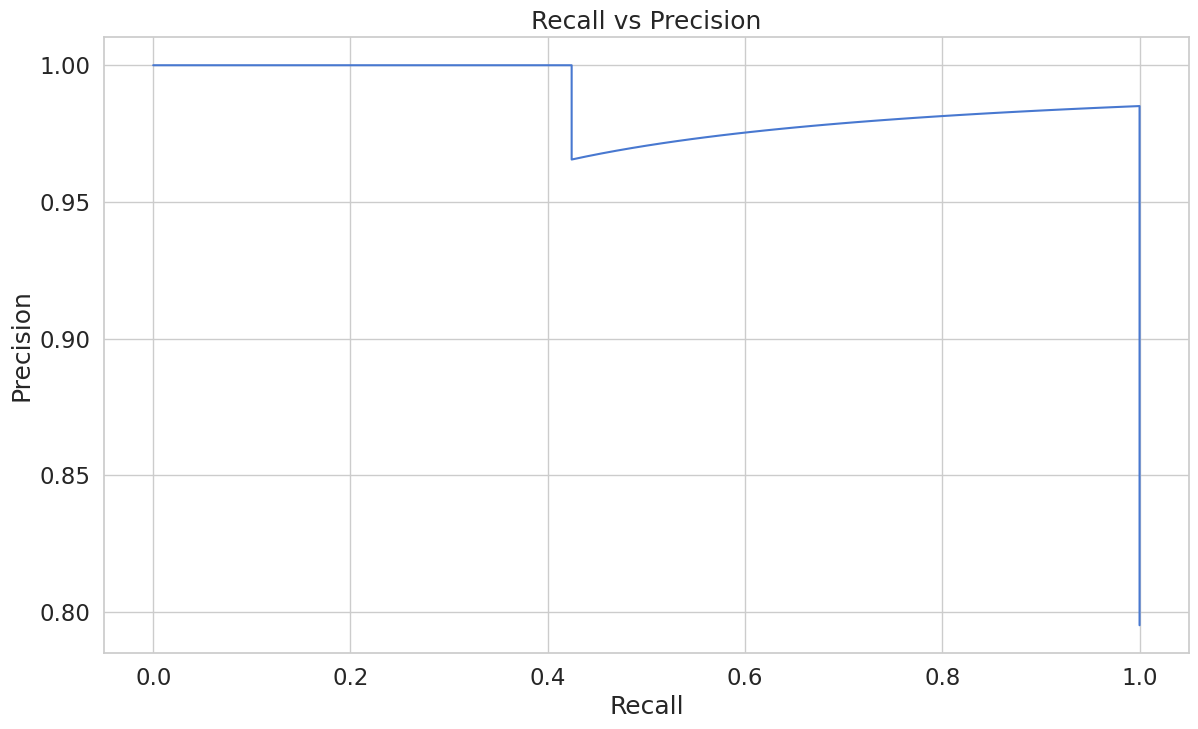

In [ ]:
precision, recall, th = precision_recall_curve(reconstructionErrorDF.Возраст_дома, reconstructionErrorDF.pred_loss)
plt.plot(recall, precision, 'b', label='Precision-Recall curve')
plt.title('Recall vs Precision')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

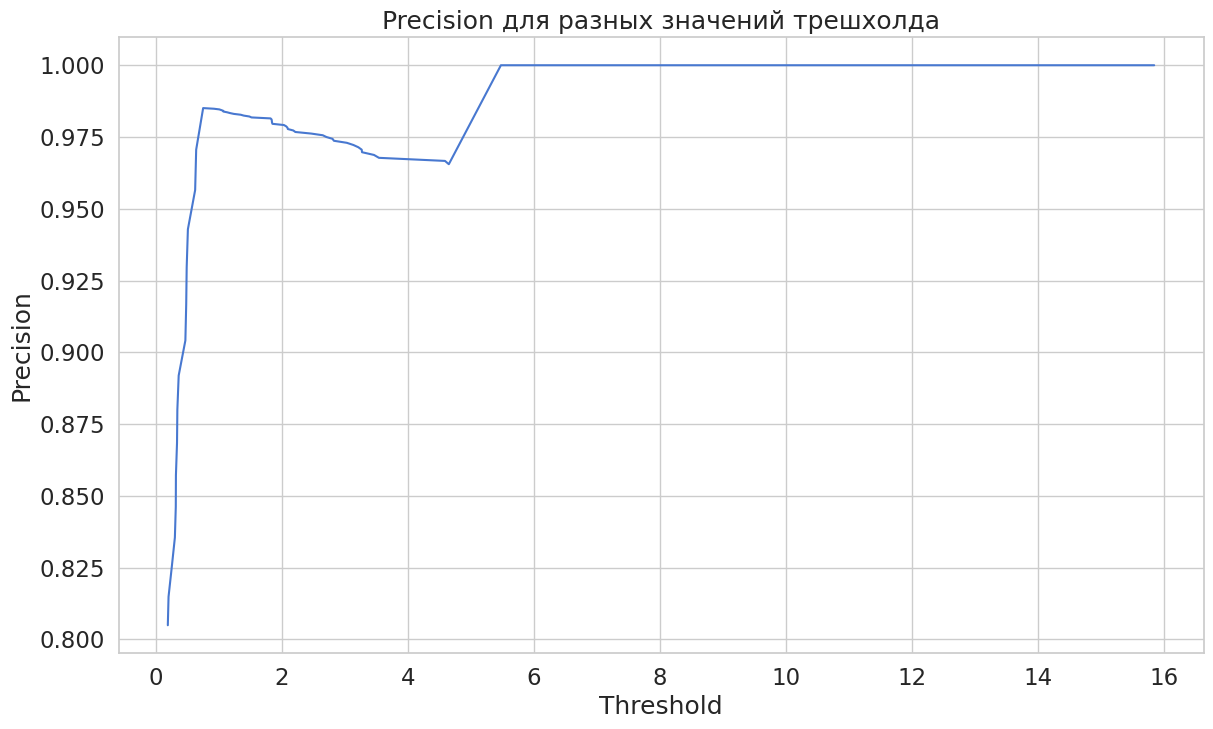

In [ ]:
plt.plot(th, precision[1:], 'b', label='Threshold-Precision curve')
plt.title('Precision для разных значений трешхолда')
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.show()

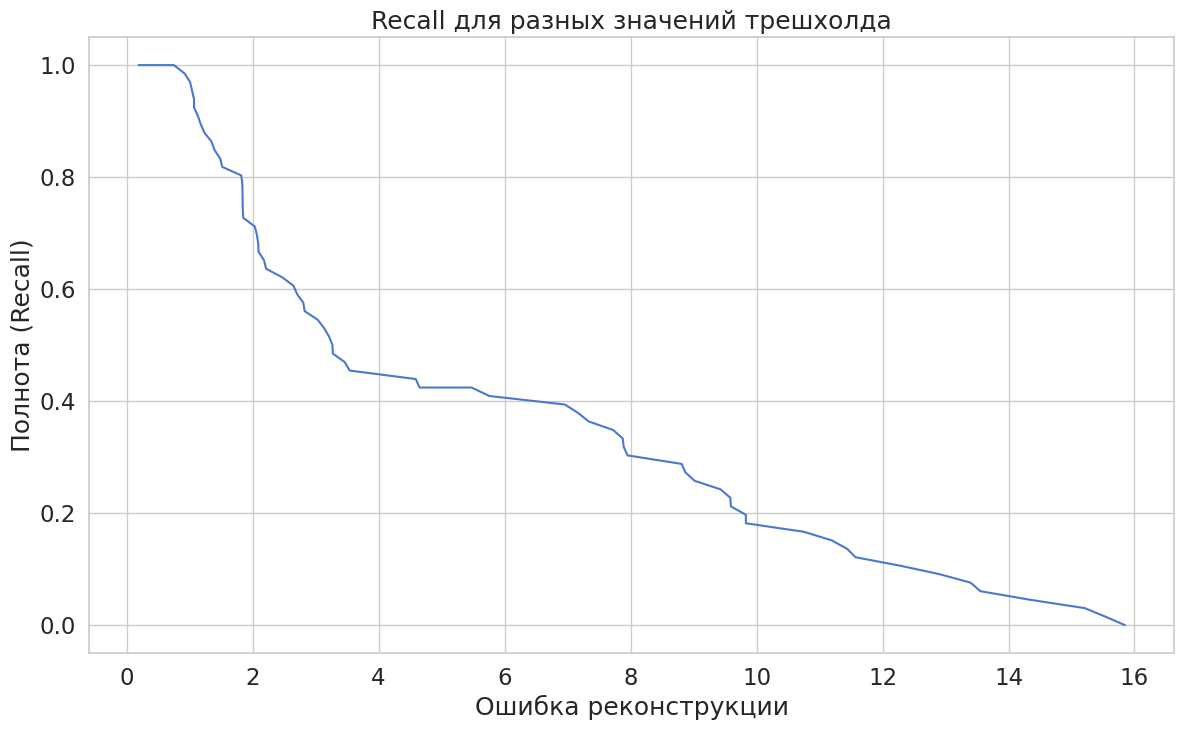

In [ ]:
plt.plot(th, recall[1:], 'b', label='Threshold-Recall curve')
plt.title('Recall для разных значений трешхолда')
plt.xlabel('Ошибка реконструкции')
plt.ylabel('Полнота (Recall)')
plt.show()

In [ ]:
threshold = 2.9

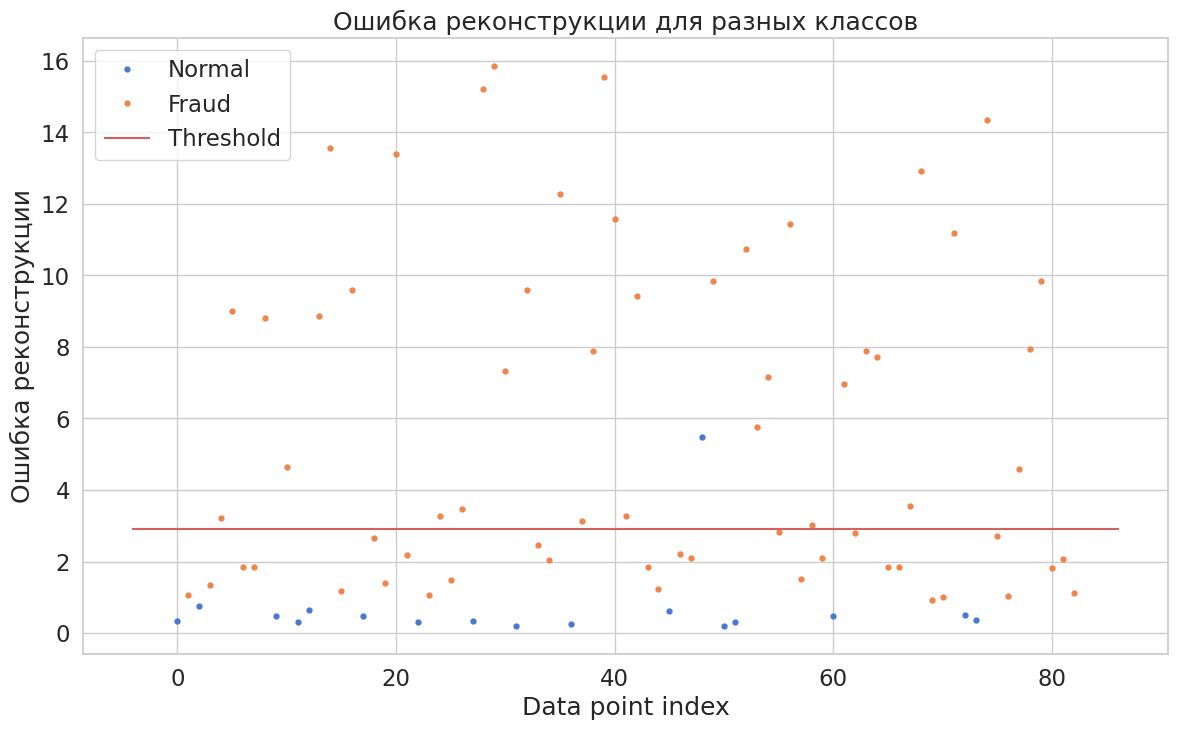

In [ ]:
groups = reconstructionErrorDF.groupby('Возраст_дома')
fig, ax = plt.subplots()

for name, group in groups:
    ax.plot(group.index, group.pred_loss, marker='o', ms=3.5, linestyle='',
            label= "Fraud" if name == 1 else "Normal")
ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r", zorder=100, label='Threshold')
ax.legend()
plt.title("Ошибка реконструкции для разных классов")
plt.ylabel("Ошибка реконструкции")
plt.xlabel("Data point index")
plt.show();

/tmp/ipykernel_3187/1307755927.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Blues'));


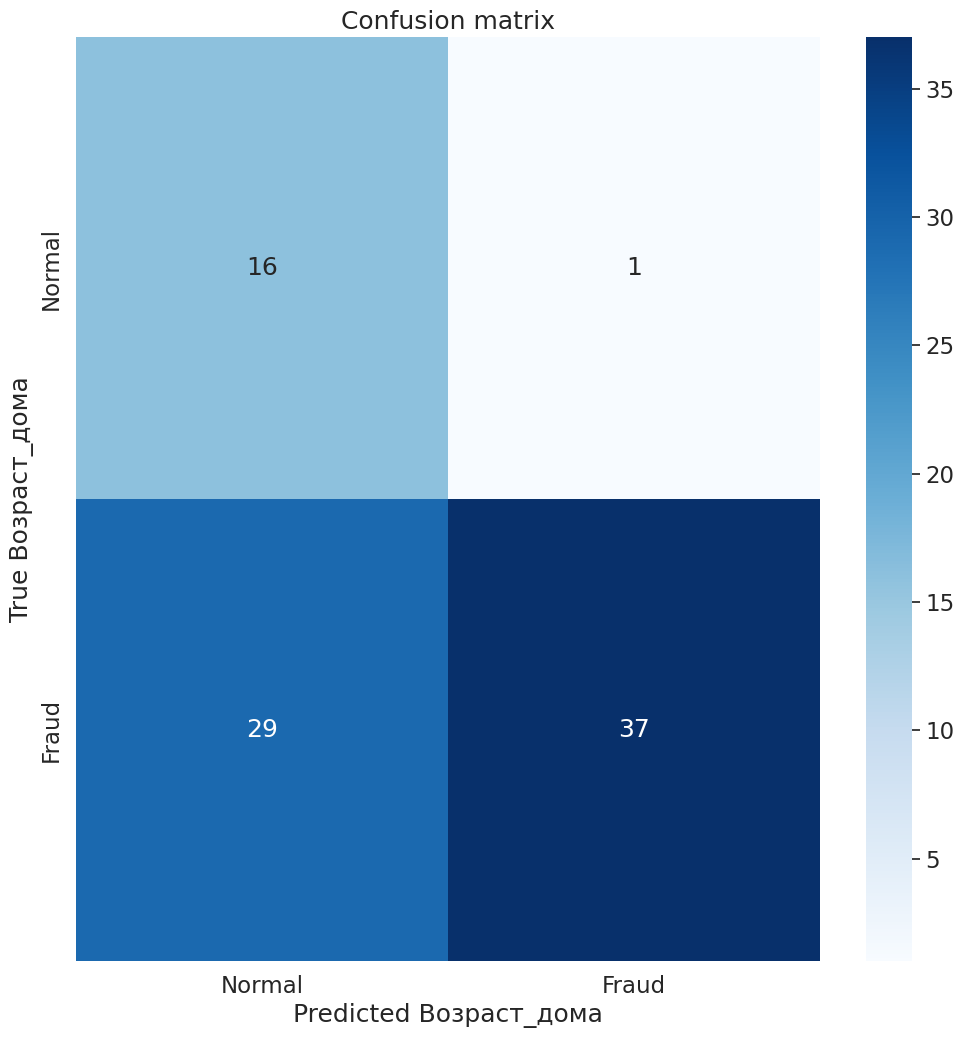

In [ ]:
y_pred = [1 if e > threshold else 0 for e in reconstructionErrorDF.pred_loss.values]
conf_matrix = confusion_matrix(reconstructionErrorDF.Возраст_дома, y_pred)
plt.figure(figsize=(12, 12))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",
            cmap=plt.cm.get_cmap('Blues'));
plt.title("Confusion matrix")
plt.ylabel('True Возраст_дома')
plt.xlabel('Predicted Возраст_дома')
plt.show()